# ResNet50网络进行图像分类

[![在线运行](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/r1.7/resource/_static/logo_modelarts.png)](https://authoring-modelarts-cnnorth4.huaweicloud.com/console/lab?share-url-b64=aHR0cHM6Ly9vYnMuZHVhbHN0YWNrLmNuLW5vcnRoLTQubXlodWF3ZWljbG91ZC5jb20vbWluZHNwb3JlLXdlYnNpdGUvbm90ZWJvb2svcjEuNy90dXRvcmlhbHMvYXBwbGljYXRpb24vemhfY24vY3YvbWluZHNwb3JlX3Jlc25ldDUwLmlweW5i&imageid=9d63f4d1-dc09-4873-b669-3483cea777c0)&emsp;[![下载Notebook](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/r1.7/resource/_static/logo_notebook.png)](https://obs.dualstack.cn-north-4.myhuaweicloud.com/mindspore-website/notebook/r1.7/tutorials/application/zh_cn/cv/mindspore_resnet50.ipynb)&emsp;[![下载样例代码](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/r1.7/resource/_static/logo_download_code.png)](https://obs.dualstack.cn-north-4.myhuaweicloud.com/mindspore-website/notebook/r1.7/tutorials/application/zh_cn/cv/mindspore_resnet50.py)&emsp;[![查看源文件](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/r1.7/resource/_static/logo_source.png)](https://gitee.com/mindspore/docs/blob/r1.7/tutorials/application/source_zh_cn/cv/resnet50.ipynb)

图像分类是最基础的计算机视觉应用，属于有监督学习类别，如给定一张图像(猫、狗、飞机、汽车等等)，判断图像所属的类别。本章将介绍使用ResNet50网络对CIFAR-10数据集进行分类。

## ResNet网络介绍

ResNet50网络是2015年由微软实验室的何恺明提出，获得ILSVRC2015图像分类竞赛第一名。在ResNet网络提出之前，传统的卷积神经网络都是将一系列的卷积层和池化层堆叠得到的，但当网络堆叠到一定深度时，就会出现退化问题。下图是在CIFAR-10数据集上使用56层网络与20层网络训练误差和测试误差图，由图中数据可以看出，56层网络比20层网络训练误差和测试误差更大，随着网络的加深，其误差并没有如预想的一样减小。

![resnet-1](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/r1.7/tutorials/application/source_zh_cn/cv/images/resnet_1.png)

ResNet网络提出了残差网络结构(Residual Network)来减轻退化问题，使用ResNet网络可以实现搭建较深的网络结构（突破1000层）。论文中使用ResNet网络在CIFAR-10数据集上的训练误差与测试误差图如下图所示，图中虚线表示训练误差，实线表示测试误差。由图中数据可以看出，ResNet网络层数越深，其训练误差和测试误差越小。

![resnet-4](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/r1.7/tutorials/application/source_zh_cn/cv/images/resnet_4.png)

> 了解ResNet网络更多详细内容，参见[ResNet论文](https://arxiv.org/pdf/1512.03385.pdf)。

## 数据集准备与加载

[CIFAR-10数据集](http://www.cs.toronto.edu/~kriz/cifar.html)共有60000张32*32的彩色图像，分为10个类别，每类有6000张图，数据集一共有50000张训练图片和10000张评估图片。如下示例使用`mindvision.classification.dataset.Cifar10`接口下载并加载CIFAR-10数据集。

In [1]:
from mindvision.classification.dataset import Cifar10

# 数据集根目录
data_dir = "./datasets"

# 加载训练集（download=False 表示不下载，使用本地文件）
dataset_train = Cifar10(path=data_dir, split='train', batch_size=6, resize=32, download=False)
ds_train = dataset_train.run()
step_size = ds_train.get_dataset_size()

# 加载测试集
dataset_val = Cifar10(path=data_dir, split='test', batch_size=6, resize=32, download=False)
ds_val = dataset_val.run()

print(f"✅ 数据集加载完成")

✅ 数据集加载完成


CIFAR-10数据集文件的目录结构如下：

```Text
datasets/
├── cifar-10-batches-py
│   ├── batches.meta
│   ├── data_batch_1
│   ├── data_batch_2
│   ├── data_batch_3
│   ├── data_batch_4
│   ├── data_batch_5
│   ├── readme.html
│   └── test_batch
└── cifar-10-python.tar.gz

```

对CIFAR-10训练数据集进行可视化。

Image shape: (6, 3, 32, 32), Label: [4 5 0 4 4 6]


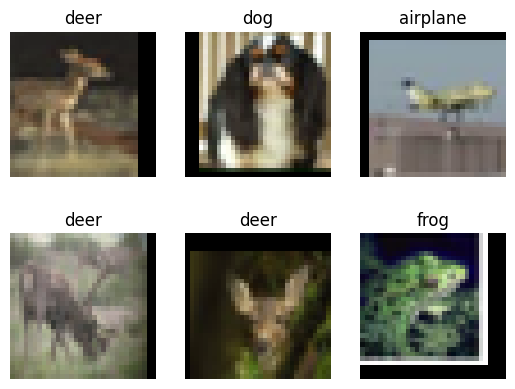

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = next(ds_train.create_dict_iterator())

images = data["image"].asnumpy()
labels = data["label"].asnumpy()
print(f"Image shape: {images.shape}, Label: {labels}")

plt.figure()
for i in range(1, 7):
    plt.subplot(2, 3, i)
    image_trans = np.transpose(images[i - 1], (1, 2, 0))
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    image_trans = std * image_trans + mean
    image_trans = np.clip(image_trans, 0, 1)
    plt.title(f"{dataset_train.index2label[labels[i - 1]]}")
    plt.imshow(image_trans)
    plt.axis("off")
plt.show()

## 构建网络

残差网络结构(Residual Network)是ResNet网络的主要亮点，ResNet使用残差网络结构后可有效地减轻退化问题，实现更深的网络结构设计，提高网络的训练精度。本节首先讲述如何构建残差网络结构，然后通过堆叠残差网络来构建ResNet50网络。

### 构建残差网络结构

残差网络结构图如下图所示，残差网络由两个分支构成：一个主分支，一个shortcuts（图中弧线表示）。主分支通过堆叠一系列的卷积操作得到，shotcuts从输入直接到输出，主分支输出的特征矩阵$F(x)$加上shortcuts输出的特征矩阵$x$得到$F(x)+x$，通过Relu激活函数后即为残差网络最后的输出。

![residual](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/r1.7/tutorials/application/source_zh_cn/cv/images/resnet_3.png)

残差网络结构主要由两种，一种是Building Block，适用于较浅的ResNet网络，如ResNet18和ResNet34；另一种是Bottleneck，适用于层数较深的ResNet网络，如ResNet50、ResNet101和ResNet152。

#### Building Block

Building Block结构图如下图所示，主分支有两层卷积网络结构：

+ 主分支第一层网络以输入channel为64为例，首先通过一个$3\times3$的卷积层，然后通过Batch Normalization层，最后通过Relu激活函数层，输出channel为64；
+ 主分支第二层网络的输入channel为64，首先通过一个$3\times3$的卷积层，然后通过Batch Normalization层，输出channel为64。

最后将主分支输出的特征矩阵与shortcuts输出的特征矩阵相加，通过Relu激活函数即为Building Block最后的输出。

![building-block-5](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/r1.7/tutorials/application/source_zh_cn/cv/images/resnet_5.png)

主分支与shortcuts输出的特征矩阵相加时，需要保证主分支与shortcuts输出的特征矩阵shape相同。如果主分支与shortcuts输出的特征矩阵shape不相同，如输出channel是输入channel的一倍时，shortcuts上需要使用数量与输出channel相等，大小为$1\times1$的卷积核进行卷积操作；若输出的图像较输入图像缩小一倍，则要设置shortcuts中卷积操作中的`stride`为2，主分支第一层卷积操作的`stride`也需设置为2。

如下代码定义`ResidualBlockBase`类实现Building Block结构。

In [3]:
from typing import Type, Union, List, Optional
from mindvision.classification.models.blocks import ConvNormActivation
from mindspore import nn


class ResidualBlockBase(nn.Cell):
    expansion: int = 1  # 最后一个卷积核数量与第一个卷积核数量相等

    def __init__(self, in_channel: int, out_channel: int,
                 stride: int = 1, norm: Optional[nn.Cell] = None,
                 down_sample: Optional[nn.Cell] = None) -> None:
        super(ResidualBlockBase, self).__init__()
        if not norm:
            norm = nn.BatchNorm2d

        self.conv1 = ConvNormActivation(in_channel, out_channel,
                                        kernel_size=3, stride=stride, norm=norm)
        self.conv2 = ConvNormActivation(out_channel, out_channel,
                                        kernel_size=3, norm=norm, activation=None)
        self.relu = nn.ReLU()
        self.down_sample = down_sample

    def construct(self, x):
        """ResidualBlockBase construct."""
        identity = x  # shortcuts分支

        out = self.conv1(x)  # 主分支第一层：3*3卷积层
        out = self.conv2(out)  # 主分支第二层：3*3卷积层

        if self.down_sample:
            identity = self.down_sample(x)
        out += identity  # 输出为主分支与shortcuts之和
        out = self.relu(out)

        return out

#### Bottleneck

Bottleneck结构图如下图所示，在输入相同的情况下Bottleneck结构相对Building Block结构的参数数量更少，更适合层数较深的网络，ResNet50使用的残差结构就是Bottleneck。该结构的主分支有三层卷积结构，分别为$1\times1$的卷积层、$3\times3$卷积层和$1\times1$的卷积层，其中$1\times1$的卷积层分别起降维和升维的作用。

+ 主分支第一层网络以输入channel为256为例，首先通过数量为64，大小为$1\times1$的卷积核进行降维，然后通过Batch Normalization层，最后通过Relu激活函数层，其输出channel为64；
+ 主分支第二层网络通过数量为64，大小为$3\times3$的卷积核提取特征，然后通过Batch Normalization层，最后通过Relu激活函数层，其输出channel为64；
+ 主分支第三层通过数量为256，大小$1\times1$的卷积核进行升维，然后通过Batch Normalization层，其输出channel为256。

最后将主分支输出的特征矩阵与shortcuts输出的特征矩阵相加，通过Relu激活函数即为Bottleneck最后的输出。

![building-block-6](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/r1.7/tutorials/application/source_zh_cn/cv/images/resnet_6.png)

主分支与shortcuts输出的特征矩阵相加时，需要保证主分支与shortcuts输出的特征矩阵shape相同。如果主分支与shortcuts输出的特征矩阵shape不相同，如输出channel是输入channel的一倍时，shortcuts上需要使用数量与输出channel相等，大小为$1\times1$的卷积核进行卷积操作；若输出的图像较输入图像缩小一倍，则要设置shortcuts中卷积操作中的`stride`为2，主分支第二层卷积操作的`stride`也需设置为2。

如下代码定义`ResidualBlock`类实现Bottleneck结构。

In [4]:
class ResidualBlock(nn.Cell):
    expansion = 4  # 最后一个卷积核的数量是第一个卷积核数量的4倍

    def __init__(self, in_channel: int, out_channel: int,
                 stride: int = 1, norm: Optional[nn.Cell] = None,
                 down_sample: Optional[nn.Cell] = None) -> None:
        super(ResidualBlock, self).__init__()
        if not norm:
            norm = nn.BatchNorm2d

        self.conv1 = ConvNormActivation(in_channel, out_channel,
                                        kernel_size=1, norm=norm)
        self.conv2 = ConvNormActivation(out_channel, out_channel,
                                        kernel_size=3, stride=stride, norm=norm)
        self.conv3 = ConvNormActivation(out_channel, out_channel * self.expansion,
                                        kernel_size=1, norm=norm, activation=None)
        self.relu = nn.ReLU()
        self.down_sample = down_sample

    def construct(self, x):
        identity = x  # shortscuts分支

        out = self.conv1(x)  # 主分支第一层：1*1卷积层
        out = self.conv2(out)  # 主分支第二层：3*3卷积层
        out = self.conv3(out)  # 主分支第三层：1*1卷积层

        if self.down_sample:
            identity = self.down_sample(x)

        out += identity  # 输出为主分支与shortcuts之和
        out = self.relu(out)

        return out

#### 构建ResNet50网络

ResNet网络层结构如下图所示，以输入彩色图像$224\times224$为例，首先通过数量64，卷积核大小为$7\times7$，stride为2的卷积层conv1，该层输出图片大小为$112\times112$，输出channel为64；然后通过一个$3\times3$的最大下采样池化层，该层输出图片大小为$56\times56$，输出channel为64；再堆叠4个残差网络块（conv2_x、conv3_x、conv4_x和conv5_x），此时输出图片大小为$7\times7$，输出channel为2048；最后通过一个平均池化层、全连接层和softmax，得到分类概率。

![resnet-layer](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/r1.7/tutorials/application/source_zh_cn/cv/images/resnet_2.png)

对于每个残差网络块，以ResNet50网络中的conv2_x为例，其由3个Bottleneck结构堆叠而成，每个Bottleneck输入的channel为64，输出channel为256。

如下示例定义`make_layer`实现残差块的构建，其参数如下所示:

+ `last_out_channel`：上一个残差网络输出的通道数。
+ `block`：残差网络的类别，分别为`ResidualBlockBase`和`ResidualBlock`。
+ `channel`：残差网络输入的通道数。
+ `block_nums`：残差网络块堆叠的个数。
+ `stride`：卷积移动的步幅。

In [5]:
def make_layer(last_out_channel, block: Type[Union[ResidualBlockBase, ResidualBlock]],
               channel: int, block_nums: int, stride: int = 1):
    down_sample = None  # shortcuts分支

    if stride != 1 or last_out_channel != channel * block.expansion:
        down_sample = ConvNormActivation(last_out_channel, channel * block.expansion,
                                         kernel_size=1, stride=stride, norm=nn.BatchNorm2d, activation=None)

    layers = []
    layers.append(block(last_out_channel, channel, stride=stride, down_sample=down_sample, norm=nn.BatchNorm2d))

    in_channel = channel * block.expansion
    # 堆叠残差网络
    for _ in range(1, block_nums):
        layers.append(block(in_channel, channel, norm=nn.BatchNorm2d))

    return nn.SequentialCell(layers)

ResNet50网络共有5个卷积结构，一个平均池化层，一个全连接层，以CIFAR-10数据集为例：

+ **conv1**：输入图片大小为$32\times32$，输入channel为3。首先经过一个卷积核数量为64，卷积核大小为$7\times7$，stride为2的卷积层；然后通过一个Batch Normalization层；最后通过Reul激活函数。该层输出feature map大小为$16\times16$，输出channel为64。
+ **conv2_x**：输入feature map大小为$16\times16$，输入channel为64。首先经过一个卷积核大小为$3\times3$，stride为2的最大下采样池化操作；然后堆叠3个$[1\times1，64；3\times3，64；1\times1，256]$结构的Bottleneck。该层输出feature map大小为$8\times8$，输出channel为256。
+ **conv3_x**：输入feature map大小为$8\times8$，输入channel为256。该层堆叠4个[1×1，128；3×3，128；1×1，512]结构的Bottleneck。该层输出feature map大小为$4\times4$，输出channel为512。
+ **conv4_x**：输入feature map大小为$4\times4$，输入channel为512。该层堆叠6个[1×1，256；3×3，256；1×1，1024]结构的Bottleneck。该层输出feature map大小为$2\times2$，输出channel为1024。
+ **conv5_x**：输入feature map大小为$2\times2$，输入channel为1024。该层堆叠3个[1×1，512；3×3，512；1×1，2048]结构的Bottleneck。该层输出feature map大小为$1\times1$，输出channel为2048。
+ **average pool & fc**：输入channel为2048，输出channel为分类的类别数。

如下示例代码实现ResNet50模型的构建，通过用调函数`resnet50`即可构建ResNet50模型，函数`resnet50`参数如下：

+ `num_classes`：分类的类别数，默认类别数为1000。
+ `pretrained`：下载对应的训练模型，并加载预训练模型中的参数到网络中。

In [6]:
from mindvision.classification.models.classifiers import BaseClassifier
from mindvision.classification.models.head import DenseHead
from mindvision.classification.models.neck import GlobalAvgPooling
from mindvision.classification.utils.model_urls import model_urls
from mindvision.utils.load_pretrained_model import LoadPretrainedModel
from mindspore import context

context.set_context(mode=context.GRAPH_MODE, device_target="GPU")

class ResNet(nn.Cell):
    def __init__(self, block: Type[Union[ResidualBlockBase, ResidualBlock]],
                 layer_nums: List[int], norm: Optional[nn.Cell] = None) -> None:
        super(ResNet, self).__init__()
        if not norm:
            norm = nn.BatchNorm2d
        # 第一个卷积层，输入channel为3（彩色图像），输出channel为64
        self.conv1 = ConvNormActivation(3, 64, kernel_size=7, stride=2, norm=norm)
        # 最大池化层，缩小图片的尺寸
        self.max_pool = nn.MaxPool2d(kernel_size=3, stride=2, pad_mode='same')
        # 各个残差网络结构块定义，
        self.layer1 = make_layer(64, block, 64, layer_nums[0])
        self.layer2 = make_layer(64 * block.expansion, block, 128, layer_nums[1], stride=2)
        self.layer3 = make_layer(128 * block.expansion, block, 256, layer_nums[2], stride=2)
        self.layer4 = make_layer(256 * block.expansion, block, 512, layer_nums[3], stride=2)

    def construct(self, x):
        x = self.conv1(x)
        x = self.max_pool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        return x


def _resnet(arch: str, block: Type[Union[ResidualBlockBase, ResidualBlock]],
            layers: List[int], num_classes: int, pretrained: bool, input_channel: int):
    backbone = ResNet(block, layers)
    neck = GlobalAvgPooling()  # 平均池化层
    head = DenseHead(input_channel=input_channel, num_classes=num_classes)  # 全连接层
    model = BaseClassifier(backbone, neck, head)  # 将backbone层、neck层和head层连接起来

    if pretrained:
        # 下载并加载预训练模型
        LoadPretrainedModel(model, model_urls[arch]).run()

    return model


def resnet50(num_classes: int = 1000, pretrained: bool = False):
    "ResNet50模型"
    return _resnet("resnet50", ResidualBlock, [3, 4, 6, 3], num_classes, pretrained, 2048)
    
def resnet18(num_classes: int = 1000, pretrained: bool = False):
    """ResNet18模型"""
    return _resnet("resnet18", ResidualBlockBase, [2, 2, 2, 2], num_classes, pretrained, 512)

## 模型训练与评估

本节使用[ResNet50预训练模型](https://download.mindspore.cn/vision/classification/resnet50_224.ckpt)进行微调。调用`resnet50`构造ResNet50模型，并设置`pretrained`参数为True，将会自动下载ResNet50预训练模型，并加载预训练模型中的参数到网络中。然后定义优化器和损失函数，通过`model.train`接口对网络进行训练，将MindSpore Vision中的`mindvision.engine.callback.ValAccMonitor`接口传入回调函数中，将会打印训练的损失值和评估精度，并保存评估精度最高的ckpt文件（best.ckpt）到当前目录下。

In [7]:
from mindspore.train import Model
from mindvision.engine.callback import ValAccMonitor
import matplotlib.pyplot as plt
from mindspore import save_checkpoint

class RecordCallback(ValAccMonitor):
    def __init__(self, model, eval_dataset, num_epochs):
        super().__init__(model, eval_dataset, num_epochs)
        self.train_losses = []
        self.train_accs = []
        self.current_epoch = 0
    
    def epoch_end(self, run_context):
        cb_params = run_context.original_args()
        self.current_epoch += 1
        
        # 记录 loss
        if hasattr(cb_params, 'net_outputs') and cb_params.net_outputs is not None:
            loss = float(cb_params.net_outputs.asnumpy().mean())
        else:
            loss = 0.0
        self.train_losses.append(loss)
        
        # 注意：ValAccMonitor 会在父类中处理验证
        # 验证精度会由父类打印，我们这里先记录占位值
        # 实际精度可以在训练后从输出中获取，或者重新评估
        self.train_accs.append(0.0)  # 占位，实际精度见打印输出
        
        # 调用父类方法（会打印验证信息）
        super().epoch_end(run_context)
    
    def get_accuracies(self, model, eval_dataset):
        """训练完成后重新评估获取每轮精度"""
        # 这个方法可以帮你从保存的最佳模型中获取精度
        acc = model.eval(eval_dataset, dataset_sink_mode=False)['Accuracy']
        return acc


# 加载数据集
from mindvision.classification.dataset import Cifar10
data_dir = "./datasets"

dataset_train = Cifar10(path=data_dir, split='train', batch_size=6, resize=32, download=False)
ds_train = dataset_train.run()
step_size = ds_train.get_dataset_size()

dataset_val = Cifar10(path=data_dir, split='test', batch_size=6, resize=32, download=False)
ds_val = dataset_val.run()


# 创建网络
network = resnet18(num_classes=10, pretrained=False)

in_channel = network.head.dense.in_channels
head = DenseHead(input_channel=in_channel, num_classes=10)
network.head = head

# 训练参数
num_epochs = 40
lr = nn.cosine_decay_lr(min_lr=0.00001, max_lr=0.001, 
                        total_step=step_size * num_epochs,
                        step_per_epoch=step_size, decay_epoch=num_epochs)

opt = nn.Momentum(params=network.trainable_params(), learning_rate=lr, momentum=0.9)
loss = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction='mean')

model = Model(network, loss, opt, metrics={"Accuracy": nn.Accuracy()})

# 训练
callback = RecordCallback(model, ds_val, num_epochs)
model.train(num_epochs, ds_train, callbacks=[callback])

# 保存模型
save_checkpoint(network, "cifar10resnet18.ckpt")
print("✅ 模型已保存为: cifar10resnet18.ckpt")

--------------------
Epoch: [  1 /  40], Train Loss: [1.999], Accuracy:  0.423
--------------------
Epoch: [  2 /  40], Train Loss: [1.649], Accuracy:  0.519
--------------------
Epoch: [  3 /  40], Train Loss: [1.040], Accuracy:  0.597
--------------------
Epoch: [  4 /  40], Train Loss: [0.650], Accuracy:  0.649
--------------------
Epoch: [  5 /  40], Train Loss: [1.156], Accuracy:  0.656
--------------------
Epoch: [  6 /  40], Train Loss: [0.465], Accuracy:  0.696
--------------------
Epoch: [  7 /  40], Train Loss: [0.819], Accuracy:  0.691
--------------------
Epoch: [  8 /  40], Train Loss: [1.899], Accuracy:  0.732
--------------------
Epoch: [  9 /  40], Train Loss: [0.720], Accuracy:  0.734
--------------------
Epoch: [ 10 /  40], Train Loss: [1.246], Accuracy:  0.748
--------------------
Epoch: [ 11 /  40], Train Loss: [0.640], Accuracy:  0.749
--------------------
Epoch: [ 12 /  40], Train Loss: [0.199], Accuracy:  0.755
--------------------
Epoch: [ 13 /  40], Train Loss:

```Text
--------------------
Epoch: [  0 /  40], Train Loss: [2.733], Accuracy:  0.274
--------------------
Epoch: [  1 /  40], Train Loss: [2.877], Accuracy:  0.319
--------------------
Epoch: [  2 /  40], Train Loss: [2.438], Accuracy:  0.249
--------------------
Epoch: [  3 /  40], Train Loss: [1.532], Accuracy:  0.386

······

Epoch: [ 37 /  40], Train Loss: [1.142], Accuracy:  0.738
--------------------
Epoch: [ 38 /  40], Train Loss: [0.402], Accuracy:  0.727
--------------------
Epoch: [ 39 /  40], Train Loss: [2.031], Accuracy:  0.735
--------------------
Epoch: [ 40 /  40], Train Loss: [0.582], Accuracy:  0.745
================================================================================
End of validation the best Accuracy is:  0.754, save the best ckpt file in ./best.ckpt

```

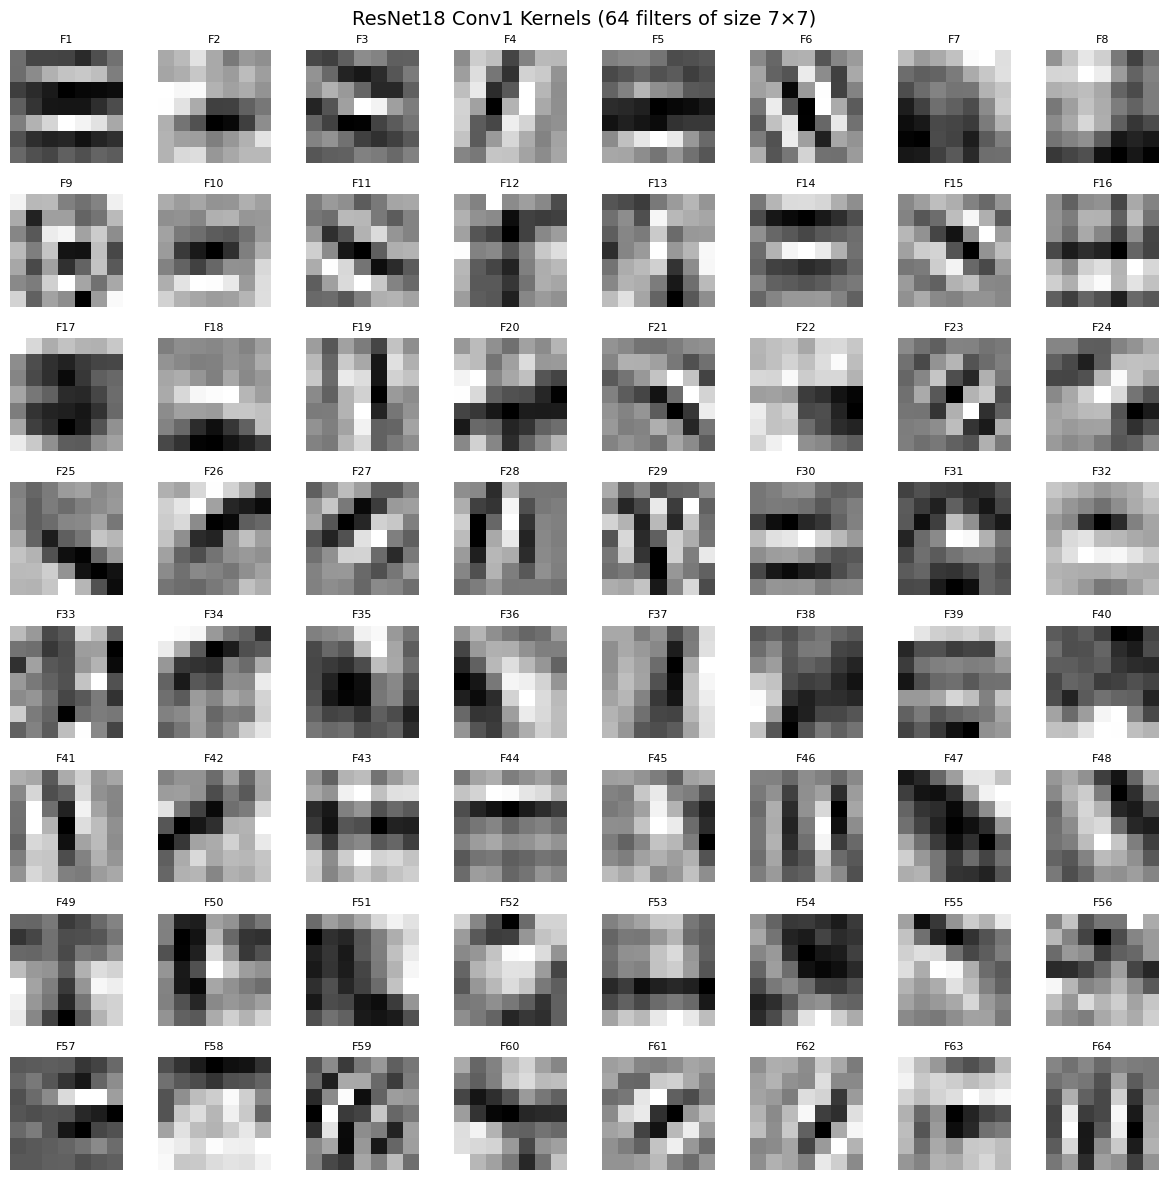

卷积核图片已保存为: conv1_kernels.png


In [15]:
import matplotlib.pyplot as plt

# 通过正确的参数名获取权重
for name, param in network.parameters_and_names():
    if name == 'backbone.conv1.features.0.weight':
        conv1_weights = param.asnumpy()
        break

# 可视化 64 个卷积核
fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    if i < 64:
        kernel = conv1_weights[i].mean(axis=0)  # 3通道取平均，变成 (7, 7)
        ax.imshow(kernel, cmap='gray')
        ax.set_title(f'F{i+1}', fontsize=8)
    ax.axis('off')

plt.suptitle('ResNet18 Conv1 Kernels (64 filters of size 7×7)', fontsize=14)
plt.tight_layout()
plt.savefig('conv1_kernels.png', dpi=150, bbox_inches='tight')
plt.show()
print("卷积核图片已保存为: conv1_kernels.png")

## 可视化模型预测

定义`visualize_model`函数，使用上述验证精度最高的模型对CIFAR-10测试数据集进行预测，并将预测结果可视化。若预测字体颜色为蓝色表示为预测正确，预测字体颜色为红色则表示预测错误。

正在提取训练集特征向量...
已处理 100 个 batch
已处理 200 个 batch
已处理 300 个 batch
已处理 400 个 batch
已处理 500 个 batch
已处理 600 个 batch
已处理 700 个 batch
已处理 800 个 batch
已处理 900 个 batch
已处理 1000 个 batch
已处理 1100 个 batch
已处理 1200 个 batch
已处理 1300 个 batch
已处理 1400 个 batch
已处理 1500 个 batch
已处理 1600 个 batch
已处理 1700 个 batch
已处理 1800 个 batch
已处理 1900 个 batch
已处理 2000 个 batch
已处理 2100 个 batch
已处理 2200 个 batch
已处理 2300 个 batch
已处理 2400 个 batch
已处理 2500 个 batch
已处理 2600 个 batch
已处理 2700 个 batch
已处理 2800 个 batch
已处理 2900 个 batch
已处理 3000 个 batch
已处理 3100 个 batch
已处理 3200 个 batch
已处理 3300 个 batch
已处理 3400 个 batch
已处理 3500 个 batch
已处理 3600 个 batch
已处理 3700 个 batch
已处理 3800 个 batch
已处理 3900 个 batch
已处理 4000 个 batch
已处理 4100 个 batch
已处理 4200 个 batch
已处理 4300 个 batch
已处理 4400 个 batch
已处理 4500 个 batch
已处理 4600 个 batch
已处理 4700 个 batch
已处理 4800 个 batch
已处理 4900 个 batch
已处理 5000 个 batch
已处理 5100 个 batch
已处理 5200 个 batch
已处理 5300 个 batch
已处理 5400 个 batch
已处理 5500 个 batch
已处理 5600 个 batch
已处理 5700 个 batch
已处理 5800 个 batch
已处理 5900

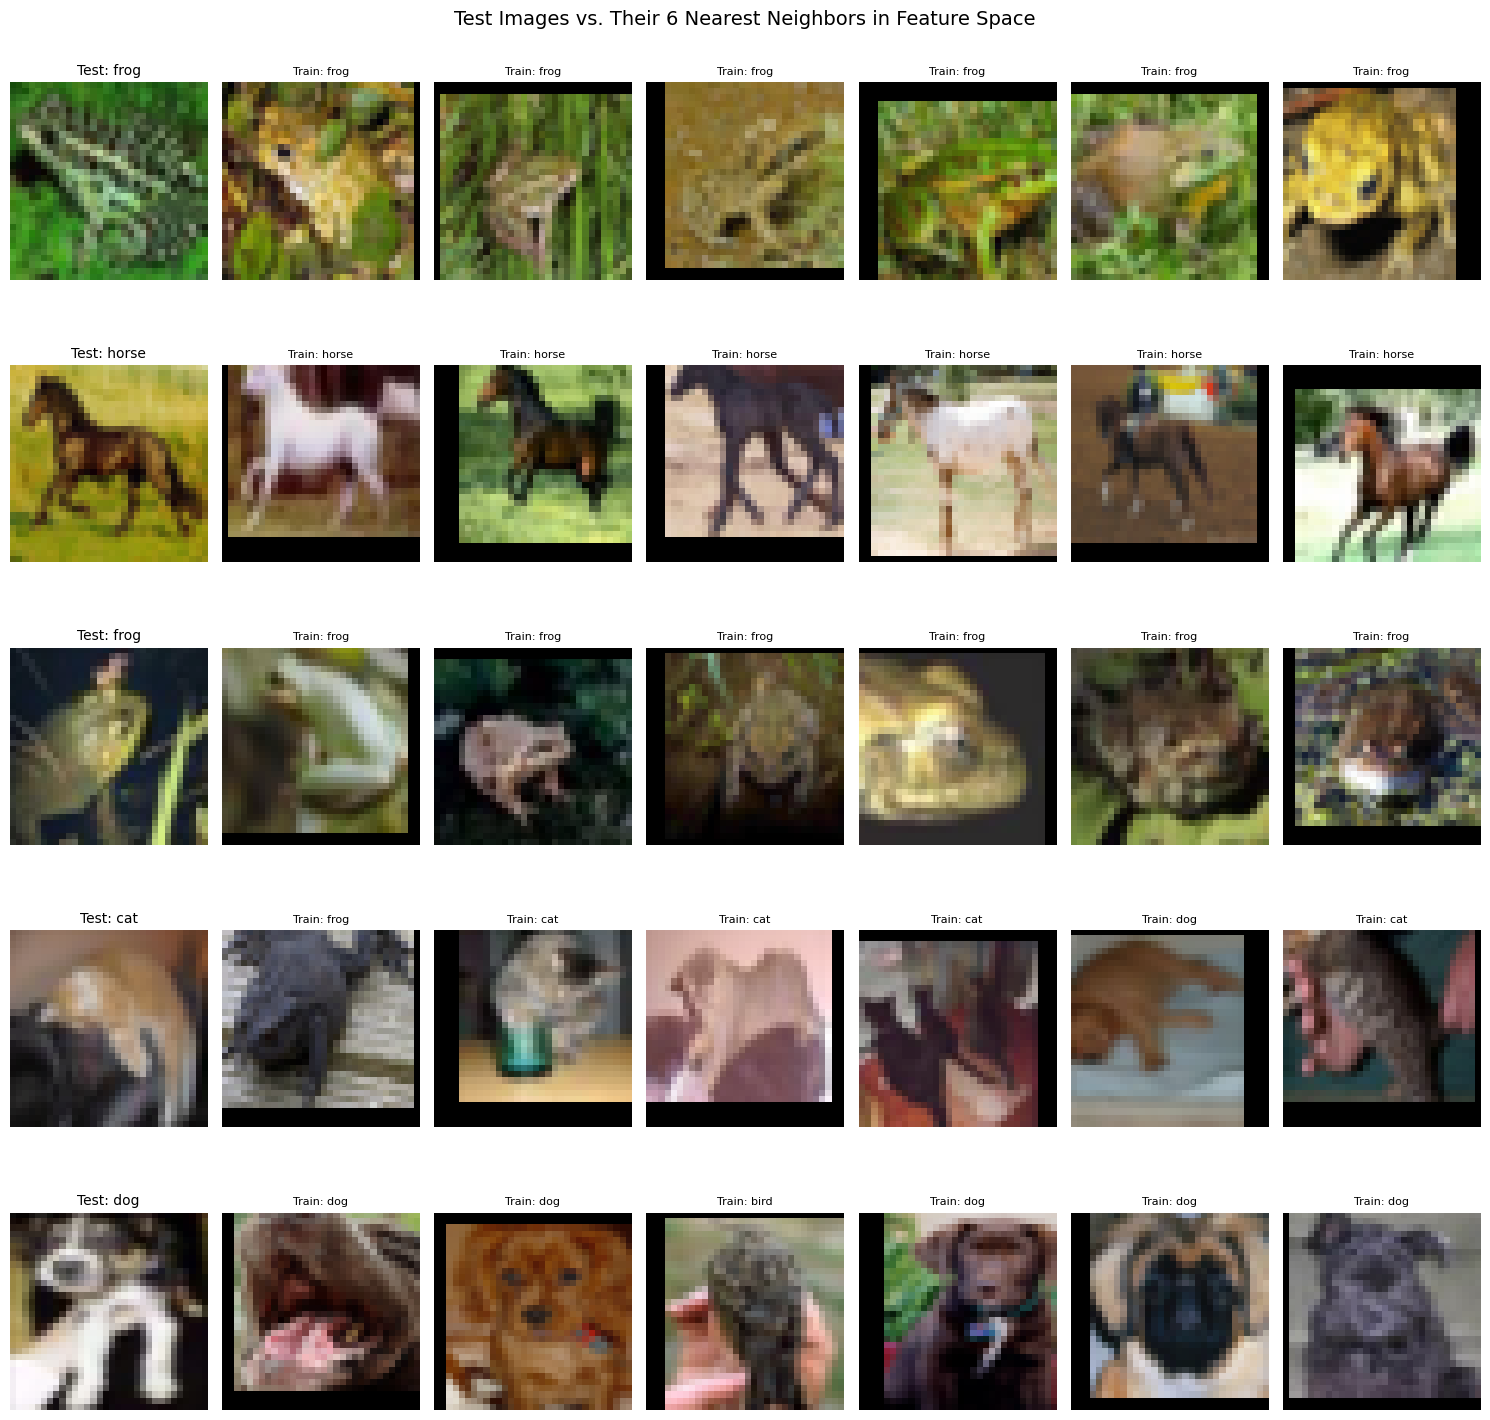

最相似图像可视化已保存为: nearest_neighbors.png


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mindspore import ops, Tensor

class FeatureExtractor(nn.Cell):
    """提取最后一层隐藏层特征（GlobalAvgPooling 的输出）"""
    def __init__(self, backbone, neck):
        super().__init__()
        self.backbone = backbone
        self.neck = neck
    
    def construct(self, x):
        x = self.backbone(x)
        x = self.neck(x)  # GlobalAvgPooling 输出特征向量
        return x

# 创建特征提取器
feature_extractor = FeatureExtractor(network.backbone, network.neck)
feature_extractor.set_train(False)  # 设置为评估模式

print("正在提取训练集特征向量...")
train_features = []
train_images = []
train_labels = []

for i, data in enumerate(ds_train.create_dict_iterator()):
    images = data["image"]
    labels = data["label"].asnumpy()
    
    # 提取特征
    features = feature_extractor(images).asnumpy()
    
    train_features.append(features)
    train_images.append(images.asnumpy())
    train_labels.append(labels)
    
    if (i + 1) % 100 == 0:
        print(f"已处理 {i + 1} 个 batch")

# 合并所有 batch 的数据
train_features = np.vstack(train_features)
train_images = np.vstack(train_images)
train_labels = np.hstack(train_labels)

print(f"训练集特征向量形状: {train_features.shape}")  # (50000, 512)
print(f"训练集图像数量: {len(train_images)}")

print("\n正在提取测试集特征向量...")
test_features = []
test_images = []
test_labels = []

for data in ds_val.create_dict_iterator():
    images = data["image"]
    labels = data["label"].asnumpy()
    
    features = feature_extractor(images).asnumpy()
    
    test_features.append(features)
    test_images.append(images.asnumpy())
    test_labels.append(labels)

test_features = np.vstack(test_features)
test_images = np.vstack(test_images)
test_labels = np.hstack(test_labels)

print(f"测试集特征向量形状: {test_features.shape}")  # (10000, 512)
print(f"测试集图像数量: {len(test_images)}")

def find_nearest_train_images(test_feat, train_feats, k=6):
    """找到与测试特征最相似的 k 个训练集特征（欧氏距离最小）"""
    # 计算欧氏距离
    distances = np.linalg.norm(train_feats - test_feat, axis=1)
    # 返回距离最小的 k 个索引
    nearest_indices = np.argsort(distances)[:k]
    return nearest_indices

def visualize_nearest_neighbors(num_test_images=5, k=6):
    """
    可视化测试图像及其最相似的 k 个训练图像
    第一列：测试图像
    后面 k 列：最相似的训练图像
    """
    np.random.seed(42)  # 固定随机种子，保证结果可复现
    test_indices = np.random.choice(len(test_images), num_test_images, replace=False)
    
    # 创建画布：num_test_images 行，k+1 列
    fig, axes = plt.subplots(num_test_images, k + 1, figsize=(15, 3 * num_test_images))
    
    # 确保 axes 是二维数组
    if num_test_images == 1:
        axes = axes.reshape(1, -1)
    
    for row, test_idx in enumerate(test_indices):
        test_img = test_images[test_idx]
        test_feat = test_features[test_idx]
        test_label = test_labels[test_idx]
        
        # 找最相似的训练图像
        nearest_indices = find_nearest_train_images(test_feat, train_features, k)
        
        # 第一列：显示测试图像
        ax = axes[row, 0]
        # 反归一化
        img_display = np.transpose(test_img, (1, 2, 0))
        mean = np.array([0.4914, 0.4822, 0.4465])
        std = np.array([0.2023, 0.1994, 0.2010])
        img_display = std * img_display + mean
        img_display = np.clip(img_display, 0, 1)
        ax.imshow(img_display)
        ax.set_title(f'Test: {dataset_val.index2label[test_label]}', fontsize=10)
        ax.axis('off')
        
        # 后面 k 列：显示最相似的训练图像
        for col, train_idx in enumerate(nearest_indices):
            ax = axes[row, col + 1]
            train_img = train_images[train_idx]
            train_label = train_labels[train_idx]
            
            # 反归一化
            img_display = np.transpose(train_img, (1, 2, 0))
            img_display = std * img_display + mean
            img_display = np.clip(img_display, 0, 1)
            ax.imshow(img_display)
            ax.set_title(f'Train: {dataset_val.index2label[train_label]}', fontsize=8)
            ax.axis('off')
    
    plt.suptitle('Test Images vs. Their 6 Nearest Neighbors in Feature Space', fontsize=14)
    plt.tight_layout()
    plt.savefig('nearest_neighbors.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("最相似图像可视化已保存为: nearest_neighbors.png")

print("\n正在生成最相似图像可视化...")
visualize_nearest_neighbors(num_test_images=5, k=6)